# MIT-BIH Arrhythmia Dataset: Exploratory Analysis & Beat Visualization

This notebook explores single-lead ECG signals from the MIT-BIH Arrhythmia Database, visualizes annotated beat types (Normal vs Ventricular vs Supraventricular), and inspects feature distributions across the AAMI DS1/DS2 inter-patient splits.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

# Add src to path
sys.path.insert(0, "../src")
from aami_mappings import SYMBOL_TO_AAMI, AAMI_CLASSES

## 1. Load and Plot ECG Record with Peak Annotations

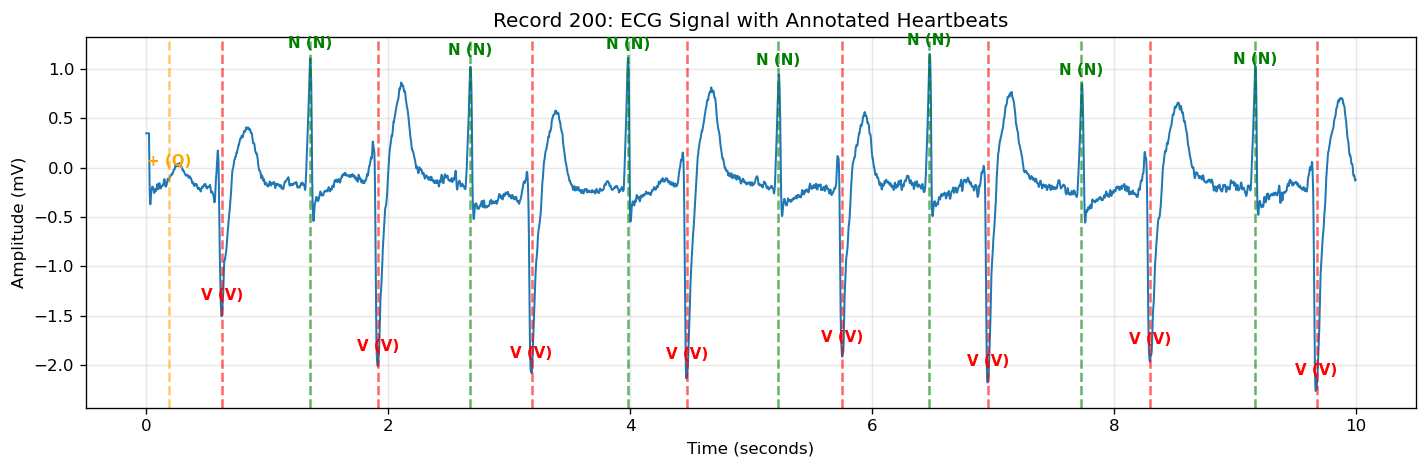

In [2]:
# Load Record 200 (contains Normal and Ventricular Ectopic Beats)
record_path = "../data/mitbih/200"
record = wfdb.rdrecord(record_path)
annotation = wfdb.rdann(record_path, 'atr')

fs = record.fs
signal = record.p_signal[:, 0] # Lead II
time = np.arange(len(signal)) / fs

# Plot first 10 seconds
idx = (time >= 0) & (time <= 10)
ann_mask = (annotation.sample >= 0) & (annotation.sample <= 10 * fs)

plt.figure(figsize=(12, 4), dpi=120)
plt.plot(time[idx], signal[idx], label='ECG Lead II', color='#1f77b4', lw=1.2)

for s, sym in zip(annotation.sample[ann_mask], np.array(annotation.symbol)[ann_mask]):
    aami_cls = SYMBOL_TO_AAMI.get(sym, 'Q')
    color = 'green' if aami_cls == 'N' else ('red' if aami_cls == 'V' else 'orange')
    plt.axvline(s / fs, color=color, linestyle='--', alpha=0.6)
    plt.text(s / fs, signal[s] + 0.15, f"{sym} ({aami_cls})", fontsize=9, ha='center', color=color, weight='bold')

plt.title('Record 200: ECG Signal with Annotated Heartbeats')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Compare Beat Waveform Morphologies (Normal vs PVC)

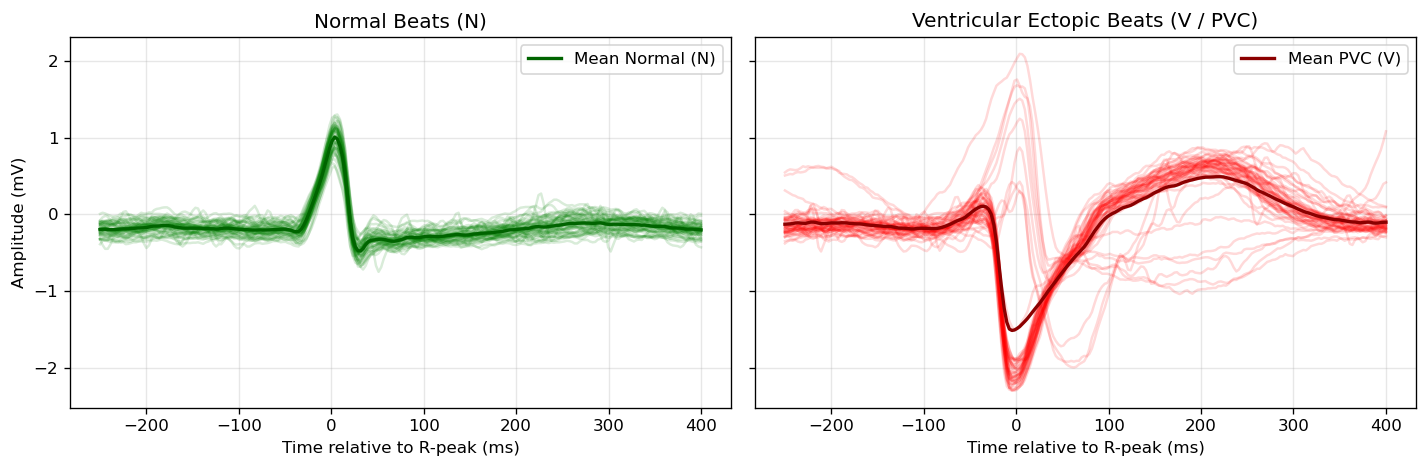

In [3]:
# Extract beat windows around R-peaks (-250ms to +400ms)
pre_samples = int(0.25 * fs)
post_samples = int(0.40 * fs)

n_beats = []
v_beats = []

for s, sym in zip(annotation.sample, annotation.symbol):
    aami = SYMBOL_TO_AAMI.get(sym, None)
    if s - pre_samples >= 0 and s + post_samples < len(signal):
        beat_win = signal[s - pre_samples : s + post_samples]
        if aami == 'N' and len(n_beats) < 50:
            n_beats.append(beat_win)
        elif aami == 'V' and len(v_beats) < 50:
            v_beats.append(beat_win)

time_ms = np.linspace(-250, 400, pre_samples + post_samples)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, dpi=120)
for b in n_beats:
    axes[0].plot(time_ms, b, color='green', alpha=0.15)
axes[0].plot(time_ms, np.mean(n_beats, axis=0), color='darkgreen', lw=2, label='Mean Normal (N)')
axes[0].set_title('Normal Beats (N)')
axes[0].set_xlabel('Time relative to R-peak (ms)')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for b in v_beats:
    axes[1].plot(time_ms, b, color='red', alpha=0.15)
axes[1].plot(time_ms, np.mean(v_beats, axis=0), color='darkred', lw=2, label='Mean PVC (V)')
axes[1].set_title('Ventricular Ectopic Beats (V / PVC)')
axes[1].set_xlabel('Time relative to R-peak (ms)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Class Distribution across DS1 (Train) and DS2 (Test) Splits

Beat distribution by split and AAMI class:


label_aami,F,N,Q,S,V
split,,,,,
ds1,414,45854,8,944,3788
ds2,388,44245,7,1837,3220


<Figure size 960x480 with 0 Axes>

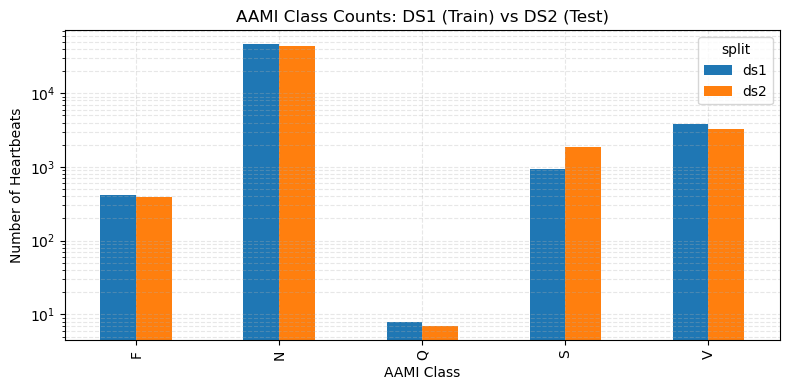

In [4]:
# Load built feature dataset if present
features_path = Path("../data/features_beat.csv")
if features_path.exists():
    df = pd.read_csv(features_path)
    col_label = 'label_aami' if 'label_aami' in df.columns else 'label'
    counts = df.groupby(['split', col_label]).size().unstack(fill_value=0)
    print("Beat distribution by split and AAMI class:")
    display(counts)
    
    plt.figure(figsize=(8, 4), dpi=120)
    ax = counts.T.plot(kind='bar', figsize=(8, 4), color=['#1f77b4', '#ff7f0e'])
    plt.title('AAMI Class Counts: DS1 (Train) vs DS2 (Test)')
    plt.xlabel('AAMI Class')
    plt.ylabel('Number of Heartbeats')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("features_beat.csv not found — run python src/dataset.py first.")